In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('ResumeDataSet.csv')
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [3]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [4]:
print(df.shape)
print(df.info())

(962, 2)
<class 'pandas.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  962 non-null    str  
 1   Resume    962 non-null    str  
dtypes: str(2)
memory usage: 15.2 KB
None


In [5]:
unique_categories = df['Category'].unique()
print(unique_categories)

<StringArray>
[             'Data Science',                        'HR',
                  'Advocate',                      'Arts',
             'Web Designing',       'Mechanical Engineer',
                     'Sales',        'Health and fitness',
            'Civil Engineer',            'Java Developer',
          'Business Analyst',             'SAP Developer',
        'Automation Testing',    'Electrical Engineering',
        'Operations Manager',          'Python Developer',
           'DevOps Engineer', 'Network Security Engineer',
                       'PMO',                  'Database',
                    'Hadoop',             'ETL Developer',
          'DotNet Developer',                'Blockchain',
                   'Testing']
Length: 25, dtype: str


In [6]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

## Data Visualization

In [7]:
import re
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer 
import string
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package stopwords to /Users/ayush/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/ayush/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [8]:
def resumeKeywords(txt):   
    cleanText = re.sub(r'http\S+\s', ' ', txt) 
    cleanText = re.sub(r'#\S+\s', ' ', cleanText)
    cleanText = re.sub(r'@\S+', '  ', cleanText)
    cleanText = re.sub(r'[%s]' % re.escape(r"""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText) 
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText) 
    cleanText = re.sub(r'\s+', ' ', cleanText)
    cleanText = cleanText.strip()
    
    tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(cleanText)

    words = []
    for word in tokens:
        words.append(word.lower())

    stopwords = nltk.corpus.stopwords.words('english')
    words_new = []
    for word in words:
        if word not in stopwords:
            words_new.append(word)

    wn = WordNetLemmatizer() 
    lemm_text = [wn.lemmatize(word) for word in words_new]

    processed_text = ' '.join(lemm_text)
    
    return processed_text

In [9]:
resumeKeywords(" https://www.github.com Software Engineer with 2 years of experience in Data Structures and Algorithms Agile Scrum, SDLC, C++, Java MVC, JavaScript, Web Development, Python " +
               "Data Science, Machine Learning / AI, and Mainframe technologies Programming Languages: 	C/C++, Java, Python, SQL, JCL, Cobol, DB2" + 
               "Frameworks: %#####	Java Spring, Spring boot, React, Angular, NodeJs" +
               "Tools: 	GIT, Visual Studio Code, Sublime, Spyder, Jupyter Notebook, Bluezone, Netbeans, Jira, Confluence, Kanban, CI/CD (Jenkins, GitLab, Azure-Devops), AWS," + 
               "Data-Bricks Libraries: 	NumPy, Pandas, Matplotlib, nltk, Scikit learn, TensorFlow, Keras Other: 	Problem-Solving, Quick Learner, Time-Management")


'software engineer 2 year experience data structure algorithm agile scrum sdlc c java mvc javascript web development python data science machine learning ai mainframe technology programming language c c java python sql jcl cobol db2frameworks java spring spring boot react angular nodejstools git visual studio code sublime spyder jupyter notebook bluezone netbeans jira confluence kanban ci cd jenkins gitlab azure devops aws data brick library numpy panda matplotlib nltk scikit learn tensorflow kera problem solving quick learner time management'

In [10]:
df['Processed_Resume'] = df['Resume'].apply(lambda x: resumeKeywords(x))
df.head()

,Category,Resume,Processed_Resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skill programming language python panda numpy ...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education detail may 2013 may 2017 b e uit rgp...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",area interest deep learning control system des...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skill r python sap hana tableau sap hana sql s...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education detail mca ymcaust faridabad haryana...


In [11]:
!pip install wordcloud
from wordcloud import WordCloud

In [12]:
label = LabelEncoder()
df['Encoded_Category'] = label.fit_transform(df['Category'])
df.head()

,Category,Resume,Processed_Resume,Encoded_Category
0,Data Science,Skills * Programming Languages: Python (pandas...,skill programming language python panda numpy ...,6
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education detail may 2013 may 2017 b e uit rgp...,6
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",area interest deep learning control system des...,6
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skill r python sap hana tableau sap hana sql s...,6
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education detail mca ymcaust faridabad haryana...,6


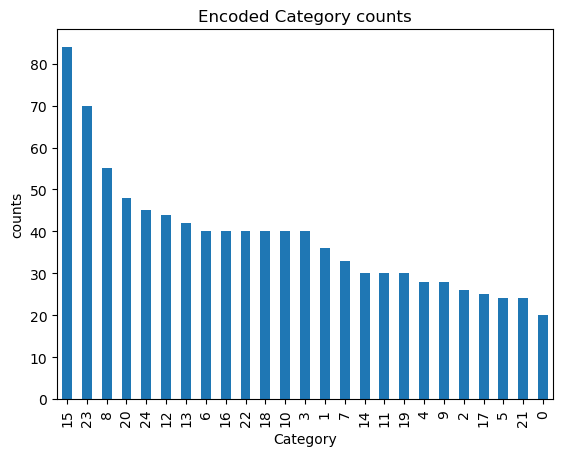

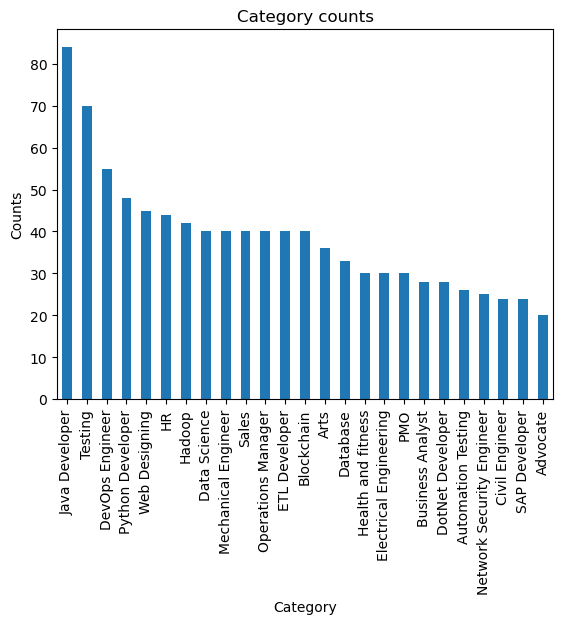

In [13]:
df['Encoded_Category'].value_counts().plot(kind = 'bar', title='Encoded Category counts', xlabel='Category', ylabel='counts')
plt.show()
df['Category'].value_counts().plot(kind = 'bar', title='Category counts', xlabel='Category', ylabel='Counts')
plt.show()

In [14]:
category_mapping={ 15: "Java Developer", 23: "Testing", 8: "DevOps Engineer", 20: "Python Developer", 24: "Web Designing", 12: "HR",
    13: "Hadoop", 3: "Blockchain", 10: "ETL Developer", 18: "Operations Manager", 6: "Data Science", 22: "Sales", 16: "Mechanical Engineer",
    1: "Arts", 7: "Database", 11: "Electrical Engineering", 14: "Health and fitness", 19: "PMO", 4: "Business Analyst", 9: "DotNet Developer",
    2: "Automation Testing", 17: "Network Security Engineer", 21: "SAP Developer", 5: "Civil Engineer", 0: "Advocate",
}

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')

tfidf.fit(df['Processed_Resume'])
requiredText  = tfidf.transform(df['Processed_Resume'])
print(requiredText)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 155341 stored elements and shape (962, 6562)>
  Coords	Values
  (0, 118)	0.06453783899846323
  (0, 268)	0.04632697838273315
  (0, 298)	0.031126979945512483
  (0, 317)	0.025361912989866155
  (0, 340)	0.033319272390464866
  (0, 370)	0.029288428444891598
  (0, 495)	0.13903194496767213
  (0, 497)	0.07851286854091813
  (0, 500)	0.15656008367123686
  (0, 505)	0.02096423266463051
  (0, 512)	0.026190077390818307
  (0, 523)	0.04632697838273315
  (0, 526)	0.03727134831379874
  (0, 622)	0.04632697838273315
  (0, 640)	0.053810183291968954
  (0, 643)	0.08098518487138881
  (0, 645)	0.02899820504264113
  (0, 646)	0.06518168127424176
  (0, 650)	0.10712314267369262
  (0, 667)	0.03771995525102985
  (0, 700)	0.027461726023211917
  (0, 703)	0.03503454597093106
  (0, 786)	0.015483241225769256
  (0, 796)	0.08098518487138881
  (0, 829)	0.024012779374943182
  :	:
  (961, 5265)	0.040106642718727006
  (961, 5313)	0.034685407248807254
  (961, 5323)	0.

## Model Training

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(requiredText, df['Encoded_Category'], test_size=0.25, random_state=42)

print(X_train.shape)
print(X_test.shape)

(721, 6562)
(241, 6562)


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = OneVsRestClassifier(KNeighborsClassifier())
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
print('Accuracy: ', accuracy_score(y_test,y_pred)*100, ' %')
print(classification_report(y_test, y_pred))

Accuracy:  98.3402489626556  %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00         5
           5       1.00      1.00      1.00         9
           6       1.00      0.78      0.88         9
           7       1.00      1.00      1.00         9
           8       1.00      0.88      0.94        17
           9       1.00      1.00      1.00        10
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         7
          12       1.00      1.00      1.00        15
          13       1.00      1.00      1.00         6
          14       1.00      1.00      1.00        10
          15       1.00      1.00      1.00        21
          16       1.00      1.00      1.00       

In [ ]:
import pickle
pickle.dump(knn, open('knn.pkl', 'wb'))

In [22]:
pickle.dump(tfidf, open('tfidf.pkl', 'wb'))

In [23]:
pickle.dump(label, open('encoder.pkl', 'wb'))

## Making Predictions

In [18]:
resume_1 = """I am a specialist in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Phone: 03442826192
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile programmer with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

In [21]:
import pickle

clf = pickle.load(open('knn.pkl', 'rb'))

cleaned_resume = resumeKeywords(resume_1)

input_features = tfidf.transform([cleaned_resume])

prediction_id = clf.predict(input_features)[0]

category_name = category_mapping.get(prediction_id, "Unknown")

print("Predicted Category:", category_name)
print(prediction_id)

Predicted Category: Data Science
6
